In [414]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [415]:
t_sber = pd.read_csv("..\\data\\trades\\T_SBER_30.csv", header=0)
t_sber['SBER'] = t_sber['PriceAvg'].pct_change()
t_sber['VAL'] = t_sber['SellValue'] + t_sber['BuyValue']
t_sber_avg = t_sber['VAL'].mean()
t_sber = t_sber[t_sber['VAL'] > t_sber_avg * 5]
t_sber.drop(columns=['PriceClose', 'PriceAvg', 'PriceStdDev', 'SellVolume', 'BuyVolume', 'SellValue', 'BuyValue', 'Count', 'VAL'], inplace=True)

#t_sber.info()
#t_sber.describe()


In [416]:

t_srh6 = pd.read_csv("..\\data\\trades\\T_SRH6_30.csv", header=0)
t_srh6['SBRF-3.26'] = t_srh6['PriceAvg'].pct_change()
t_srh6.drop(columns=['PriceClose', 'PriceAvg', 'PriceStdDev', 'SellVolume', 'BuyVolume', 'SellValue', 'BuyValue', 'Count'], inplace=True)

t_srm6 = pd.read_csv("..\\data\\trades\\T_SRM6_30.csv", header=0)
t_srm6['SBRF-6.26'] = t_srm6['PriceAvg'].pct_change()
t_srm6.drop(columns=['PriceClose', 'PriceAvg', 'PriceStdDev', 'SellVolume', 'BuyVolume', 'SellValue', 'BuyValue', 'Count'], inplace=True)

df1 = pd.merge(t_sber, t_srh6, on='TimeUtc')
df = pd.merge(df1, t_srm6, on='TimeUtc')



In [417]:
df['SBER']= df['SBER'].shift(1)

df.dropna(inplace=True)
#df

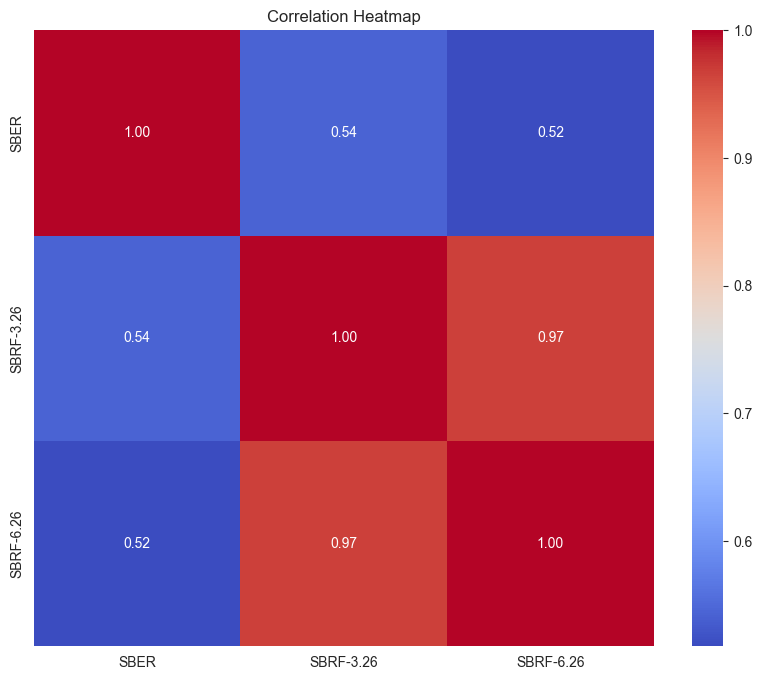

In [418]:

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()
